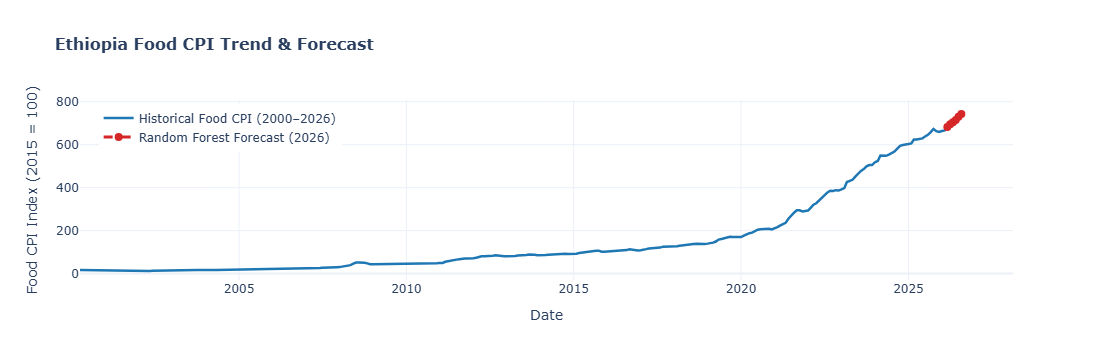

In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor


raw_df = pd.read_csv("eth_faostat_consumer_price_indices.csv")

item_filter = "Consumer Prices, Food Indices (2015 = 100)"
df = raw_df[raw_df["Item"] == item_filter].copy()

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df["Months_Code_Num"] = pd.to_numeric(df["Months Code"], errors="coerce")
df["Month"] = (df["Months_Code_Num"] - 7000).astype(int)

df = (
    df.dropna(subset=["Year", "Month", "Value"])
    .sort_values(by=["Year", "Month"])
    .reset_index(drop=True)
)

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)
df["Date_Label"] = df["Date"].dt.strftime("%B %Y")

df["MoM_Growth_%"] = df["Value"].pct_change() * 100
df["Prev_MoM_Lag1"] = df["MoM_Growth_%"].shift(1)
df["Prev_MoM_Lag2"] = df["MoM_Growth_%"].shift(2)

model_df = df.dropna(
    subset=["MoM_Growth_%", "Prev_MoM_Lag1", "Prev_MoM_Lag2"]
).copy()


X = model_df[["Month", "Prev_MoM_Lag1", "Prev_MoM_Lag2"]]
y = model_df["MoM_Growth_%"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)


mom_history = list(model_df["MoM_Growth_%"])
cpi_history = list(model_df["Value"])

current_month = int(model_df["Month"].iloc[-1])
current_year = int(model_df["Year"].iloc[-1])
current_cpi = cpi_history[-1]

forecast_dates = [pd.to_datetime(f"{current_year}-{current_month}-01")]
forecast_cpi_vals = [current_cpi]
forecast_mom_vals = [mom_history[-1]]

for _ in range(5):
    current_month = 1 if current_month == 12 else current_month + 1
    if current_month == 1:
        current_year += 1

    lag1, lag2 = mom_history[-1], mom_history[-2]
    features = pd.DataFrame(
        [
            {
                "Month": current_month,
                "Prev_MoM_Lag1": lag1,
                "Prev_MoM_Lag2": lag2,
            }
        ]
    )

    pred_growth = model.predict(features)[0]
    current_cpi *= 1 + pred_growth / 100.0

    mom_history.append(pred_growth)
    cpi_history.append(current_cpi)

    forecast_dates.append(pd.to_datetime(f"{current_year}-{current_month}-01"))
    forecast_cpi_vals.append(current_cpi)
    forecast_mom_vals.append(pred_growth)

forecast_df = pd.DataFrame(
    {
        "Date": forecast_dates,
        "Value": forecast_cpi_vals,
        "MoM_Growth_%": forecast_mom_vals,
    }
)
forecast_df["Date_Label"] = forecast_df["Date"].dt.strftime("%B %Y")


historical_hover = (
    "<b>Date:</b> %{customdata[0]}<br>"
    "<b>Food CPI:</b> %{y:.2f}<br>"
    "<b>Monthly Growth:</b> %{customdata[1]:+.2f}%<extra></extra>"
)

forecast_hover = (
    "<b>Date:</b> %{customdata[0]} (Forecast)<br>"
    "<b>Predicted CPI:</b> %{y:.2f}<br>"
    "<b>Predicted Growth:</b> %{customdata[1]:+.2f}%<extra></extra>"
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=model_df["Date"],
        y=model_df["Value"],
        mode="lines",
        name="Historical Food CPI (2000–2026)",
        line=dict(color="#1f77b4", width=2.5),
        customdata=np.stack(
            (model_df["Date_Label"], model_df["MoM_Growth_%"]), axis=-1
        ),
        hovertemplate=historical_hover,
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_df["Date"],
        y=forecast_df["Value"],
        mode="lines+markers",
        name="Random Forest Forecast (2026)",
        line=dict(color="#d62728", width=3, dash="dash"),
        marker=dict(size=8, color="#d62728"),
        customdata=np.stack(
            (forecast_df["Date_Label"], forecast_df["MoM_Growth_%"]), axis=-1
        ),
        hovertemplate=forecast_hover,
    )
)

fig.update_layout(
    title="<b>Ethiopia Food CPI Trend & Forecast</b> ",
    title_font=dict(size=16),
    xaxis_title="Date",
    yaxis_title="Food CPI Index (2015 = 100)",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(x=0.02, y=0.98),
)

fig.show()
fig.write_html("interactive_cpi_chart.html")